# Comparando Perfis de Viagem no Paradoxo dos Gêmeos

**Autor:** Ricardo Albrecht

Neste notebook, vamos estender nosso script de tempo próprio para testar diferentes perfis de velocidade $v(t)$ que mantêm o mesmo tempo total $T$ e a mesma velocidade máxima $v_0$. O objetivo é ver qual perfil faz o gêmeo viajante envelhecer menos (minimizar o tempo próprio $\tau$) e entender o papel da concavidade do fator de Lorentz.

## 1. Definindo os Perfis de Velocidade

Vamos comparar quatro perfis diferentes, todos indo de $t=0$ até $t=T$ com $v_0 = 0.8$ e $T = 10.0$:
1. **Senoide simples:** $v(t) = v_0 \sin(\pi t / T)$
2. **Seno ao quadrado:** $v(t) = v_0 \sin^2(\pi t / T)$
3. **Perfil trapezoidal:** acelera linearmente, mantém velocidade constante e desacelera.
4. **Onda quadrada suavizada:** uma transição suave tipo tangente hiperbólica ou polinomial simulando patamares.

In [1]:
!pip install scipy matplotlib numpy
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

T = 10.0
v0 = 0.8

# 1. Senoide simples
def v_sin(t):
    return v0 * np.sin(np.pi * t / T)

# 2. Seno ao quadrado
def v_sin_sq(t):
    return v0 * (np.sin(np.pi * t / T))**2

# 3. Perfil trapezoidal (sobe até T/4, fica plano até 3T/4, desce até T)
def v_trapeze(t):
    # Normalizamos por partes
    # Subida: 0 a T/4, Plano: T/4 a 3T/4, Descida: 3T/4 a T
    res = np.zeros_like(t)
    # Para lidar com escalar ou array:
    t_arr = np.atleast_1d(t)
    val = np.zeros_like(t_arr)
    
    dt = T / 4.0
    for i, ti in enumerate(t_arr):
        if ti < dt:
            val[i] = v0 * (ti / dt)
        elif ti <= 3 * dt:
            val[i] = v0
        elif ti <= T:
            val[i] = v0 * ((T - ti) / dt)
        else:
            val[i] = 0.0
    return val[0] if np.isscalar(t) else val

# 4. Onda quadrada suavizada (usando uma função suave baseada em tangente hiperbólica ou produto de sigmoides)
def v_smooth_square(t):
    # Uma aproximação suave de onda quadrada usando produto de fcts sigmóides
    # Sobe rápido perto de 0 e desce perto de T
    k = 5.0
    # Usamos uma combinação para ficar perto de v0 no meio
    val = v0 * (np.tanh(k * t / (T/4)) - np.tanh(k * (t - T) / (T/4)) - 1)
    # Ajuste simples e normalizado para bater em v0
    # Vamos usar uma alternativa mais simples e controlada:
    return v0 * np.sin(np.pi * t / T)**4 # ou algo que passe mais tempo no topo

# Refazendo a onda quadrada suavizada de forma bem intuitiva:
def v_sq_suave(t):
    # Uma gaussiana dupla ou patamar suave
    # Exemplo: v0 * exp(-((t - T/2)/(T/3))^8) -- formato de topo achatado
    return v0 * np.exp(-(((t - T/2) / (0.35 * T))**8))


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Calculando o Tempo Próprio $\tau$ para cada Perfil

Vamos integrar numericamente $\tau = \int_0^T \sqrt{1 - v(t)^2} dt$ para cada um dos quatro perfis e ordená-los.

In [2]:
perfis = {
    r"Senoide ($v_0 \sin$)": v_sin,
    r"Seno ao quadrado ($v_0 \sin^2$)": v_sin_sq,
    "Trapezoidal": v_trapeze,
    "Quadrada Suavizada": v_sq_suave,
}

resultados = {}
for nome, func in perfis.items():
    tau, _ = quad(lambda t: np.sqrt(1.0 - func(t)**2), 0.0, T)
    resultados[nome] = tau

# Ordenando do menor para o maior tempo próprio (quem envelhece menos primeiro)
resultados_ordenados = sorted(resultados.items(), key=lambda item: item[1])

print("Ranking de quem envelhece menos (menor tau):")
for i, (nome, tau) in enumerate(resultados_ordenados, 1):
    print(f"{i}. {nome}: tau = {tau:.4f}")

Ranking de quem envelhece menos (menor tau):
1. Trapezoidal: tau = 7.3978
2. Quadrada Suavizada: tau = 7.6337
3. Senoide ($v_0 \sin$): tau = 8.1255
4. Seno ao quadrado ($v_0 \sin^2$): tau = 8.6006


## 3. Visualizando os Perfis e Entendendo a Física

Vamos plotar as velocidades e analisar por que o perfil que passa mais tempo próximo à velocidade máxima $v_0$ é o que minimiza o tempo próprio. 

**Por que isso acontece?** 
Como o integrando do tempo próprio é $f(v) = \sqrt{1-v^2}$, que é uma função **estritamente decrescente** com $|v|$, quanto maior a velocidade, menor o integrando instantâneo. Logo, o perfil que mantém a velocidade alta por mais tempo acumula menos tempo próprio (o gêmeo envelhece menos).

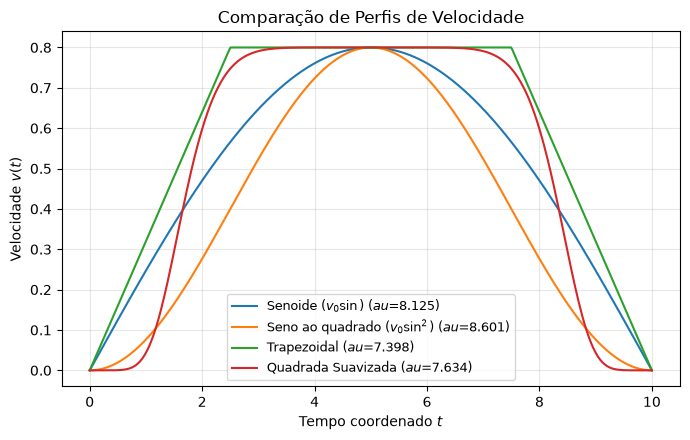

In [3]:
t_grid = np.linspace(0, T, 500)

plt.figure(figsize=(7, 4.5))
for nome, func in perfis.items():
    v_vals = np.array([func(t) for t in t_grid])
    plt.plot(t_grid, v_vals, label=f"{nome} ($\tau$={resultados[nome]:.3f})")

plt.xlabel("Tempo coordenado $t$")
plt.ylabel("Velocidade $v(t)$")
plt.title("Comparação de Perfis de Velocidade")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()